Este notebook apresenta a análise quantitativa da Base de Dados EOD, discutida no trabalho que está em processo de publicação na RBEF '*Ecos Teórico-Observacionais e Epistemológicos da Revolução Copernicana: Um Olhar para os Exoplanetas a partir das Leis de Kepler e da Epistemologia de Kuhn*'.

# Introdução

Em Física e Astronomia, as Leis de Kepler, em homenagem ao astrônomo e matemático alemão Johannes Kepler, descrevem os movimentos dos planetas de acordo com modelos em que o Sol ocupa o centro do Sistema Solar (modelos Heliocêntricos). O objetivo do trabalho é apresentar uma discussão teórica-observacional e epistemológica sobre as Três Leis de Kepler, a partir do estudo de exoplanetas. Aqui, realizaremos a análise quantitativa do trabalho.

---
# 1. Importação de bibliotecas

Começaremos importando as bibliotecas para manipulação e exibição de dados

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(context = 'notebook', palette = 'flare_r')
warnings.filterwarnings('ignore')

---
# 2. Carregamento dos dados

Os dados a serem analisados se encontrarão em dois arquivos: 
- o primeiro foi baixado do site oficial da [EOD](exoplanets.org/csv) (Exoplanets Orbit Database) e contêm os dados de **exo**planetas, planetas de fora do Sistema solar
- o segundo é uma tabela contendo dados precisos (porém sem margens de erro) dos planetas do Sistema Solar, disponíveis no site da NASA, [Planetary Fact Sheet](https://nssdc.gsfc.nasa.gov/planetary/factsheet)



In [152]:
dados = pd.read_csv('exoplanets.csv', low_memory = False)
dados.shape

(5747, 314)

In [153]:
df_planetas = {
    "NAME": ["M", "V", "T", "M", "J", "S", "U", "N"],
    "PER": [88.0, 224.7, 365.25, 687.0, 4331, 10747, 30589, 59800],  # Em dias
    "A": [57.9, 108.2, 149.6, 228.0, 778.5, 1432.0, 2867.0, 4515.0], # Em milhões de km
    "ECC": [0.206, 0.007, 0.017, 0.094, 0.049, 0.052, 0.047, 0.010]
}

planetas = pd.DataFrame(df_planetas)     # adicionando os planetas do sistema solar

Por enquanto, vamor focar a análise nos dados dos exoplanetas pois o dataframe dos planetas está quase completo

# 3. Pré-processamentos dos dados

## 3.1 Seleção dos dados
A base de dados EOD contêm 314 parâmetros de 5747 objetos.
Selecionaremos as seguintes colunas: 

- NAME : nome do exoplaneta, usado para identificação;
- ECC: excentricidade da órbita do exoplaneta;
- MSTAR : a massa da estrela hospedeira do exoplaneta;
- PER : período do exoplaneta, ou seja, o tempo que ele leva dar uma volta em torno de sua estrela;
- δECC, δMSTAR e δPER : margens de erro de cada parâmetro (representados por XUPPER ou XLOWER, X é o nome de outras colunas);
- DATE : ano em que o exoplaneta foi descoberto;
- PLANETDISCMETH : qual método foi usado em sua descoberta;

In [154]:
df_g = dados[['NAME', 'ECC', 'ECCUPPER', 'ECCLOWER', 'MSTAR', 'MSTARUPPER', 'MSTARLOWER', 'PER', 'PERUPPER', 'PERLOWER', 'DATE', 'PLANETDISCMETH']]

A tabela contêm dados do tipo [KOI](https://exoplanetarchive.ipac.caltech.edu/docs/Kepler_KOI_docs.html) (*Kepler Objects of Interest*), que são eventos periódicos que *parecem* planetas transitando a estrela, mas ainda não foram confirmado. Por isso, vamos retirá-los da amostra.

In [155]:
df_g = df_g.query("not NAME.str.contains('KOI')")     # Selecionando os objetos que não contêm 'KOI' no nome

## 3.2 Pré-Processamento

Exibindo as 3 primeiras linhas

In [156]:
df_g.head(3)

,NAME,ECC,ECCUPPER,ECCLOWER,MSTAR,MSTARUPPER,MSTARLOWER,PER,PERUPPER,PERLOWER,DATE,PLANETDISCMETH
0,Kepler-107 d,NaN,NaN,NaN,NaN,NaN,NaN,7.958203,0.000104,0.000104,2014.0,Transit
1,Kepler-1049 b,0.0,NaN,NaN,0.51,0.03,0.03,3.273461,0.000005,0.000005,2016.0,Transit
2,Kepler-813 b,0.0,NaN,NaN,0.95,0.05,0.07,19.129473,0.000075,0.000075,2016.0,Transit


Verificando o formato dos dados de cada coluna

In [157]:
df_g.dtypes # Está quase tudo certo, só vamos olhar com mais atenção aos dados da coluna DATE, que é o ano de descoberta do exoplaneta.

NAME               object
ECC               float64
ECCUPPER          float64
ECCLOWER          float64
MSTAR             float64
MSTARUPPER        float64
MSTARLOWER        float64
PER               float64
PERUPPER          float64
PERLOWER          float64
DATE              float64
PLANETDISCMETH     object
dtype: object

Vamos observar os valores da coluna DATE 


In [158]:
df_g['DATE'].unique()

array([2014., 2016., 2010., 2009., 2011., 2017., 2007., 2001., 2006.,
       2015., 2002., 2012., 2003., 2013., 2018., 2000., 2004., 2008.,
       2005., 1997., 1992., 1999., 1996., 1994., 1995., 1998., 1989.,
       1988., 1993.])

In [159]:
# Eles podem ser todos transformados em inteiros
df_g['DATE'] = df_g['DATE'].astype('int')
df_g['DATE'].dtype

dtype('int64')

Contabilizando o número de valores não nulos por coluna

In [160]:
df_g.notna().sum()     # Como há uma grande variedade de dados nulos em cada coluna, para cada análise vamos selecionar
                       # as colunas necessárias e retirar os NaNs.

NAME              3261
ECC               2404
ECCUPPER           820
ECCLOWER           820
MSTAR             2549
MSTARUPPER        2465
MSTARLOWER        2465
PER               3247
PERUPPER          3166
PERLOWER          3166
DATE              3261
PLANETDISCMETH    3260
dtype: int64

Verificando a existência de dados duplicados

In [161]:
df_g.duplicated().sum()

0

## 3.3 Análise Descritiva
Exploração das características básicas dos conjuntos

In [162]:
df_g.describe() # A variável da MSTAR, a massa da estrela hospedeira, ser 0 não faz sentido. As margens de erro serem 0.000000 também não faz sentido

,ECC,ECCUPPER,ECCLOWER,MSTAR,MSTARUPPER,MSTARLOWER,PER,PERUPPER,PERLOWER,DATE
count,2404.000000,820.000000,820.000000,2549.000000,2465.000000,2465.000000,3247.000000,3.166000e+03,3.166000e+03,3261.000000
mean,0.061670,0.080722,0.043452,0.999976,0.071193,0.068350,341.853614,5.644211e+00,6.598393e+00,2013.674333
std,0.140281,0.095585,0.045319,0.303879,0.091830,0.094552,6512.139280,7.607211e+01,1.163564e+02,3.621855
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.179715,6.000000e-09,6.000000e-09,1988.000000
25%,0.000000,0.020000,0.007959,0.850000,0.036000,0.040000,4.571667,1.322500e-05,1.332000e-05,2013.000000
50%,0.000000,0.050000,0.030000,0.990000,0.050000,0.050000,12.162701,6.856000e-05,6.900000e-05,2014.000000
75%,0.042000,0.100000,0.065000,1.130000,0.080000,0.070000,41.777934,6.000000e-04,6.000000e-04,2016.000000
max,0.970000,0.900000,0.290000,3.090000,2.450000,2.090000,318498.000000,3.414000e+03,5.329000e+03,2018.000000


## 3.4 Transformação dos dados

In [163]:
# Os períodos estão em dias, vamos colocá-los em Anos
df_g['PER'] = df_g['PER']/365
df_g['PERUPPER'] = df_g['PERUPPER']/365       
df_g['PERLOWER'] = df_g['PERLOWER']/365

Vamos calcular o semieixo maior (representado por A), a distância média dos exoplanetas até a estrela hospedeira, a partir da 3º Lei de Kepler 
$$P^2 = A^3k$$

No caso da Terra, P = 1 ano, e A = 1 UA, logo, k = 1 mais pra frente discutiremos as consequências dessa 'escolha'. Assim, obteremos A a partir da equação
$$A = P^{2/3}$$

Além disso, calcularemos a propagação de erro a partir da relação, para uma função f(x), onde A = A(P):

$$\delta f = \frac{df}{dx}\delta x$$

onde $\delta$ representa a margem de erro, tanto superior quanto inferior. Aplicando $A = P^{2/3}$ na equação anterior, encontramos que 
$$\delta A = \frac{2A}{3}\frac{\delta P}{P}$$

In [164]:
# Obtendo o semieixo maior (a distância média dos exoplanetas até sua estrela)
# com a terceira lei de Kepler
df_g['A'] = df_g['PER']**(2/3)   # Dessa forma, os dados já são obtidos em Unidades Astronômicas, distância Média da Terra ao Sol 149.6e6 km
df_g['AUPPER'] = (2/3)*df_g['A']*df_g['PERUPPER']/df_g['PER']
df_g['ALOWER'] = (2/3)*df_g['A']*df_g['PERLOWER']/df_g['PER']

Para algumas etapas da análise de dados precisaremos da velocidade de cada exoplaneta. Para isso, utilizaremos a seguinte equação:

$$v = v_T\sqrt{\frac{M}{A}}$$

onde $v_T$ é a velocidade da Terra, de 29.8 km/s, M é a massa da estrela hospedeira e A o semieixo maior.

Iniciamos calculando a velocidade diretamente da equação:

In [165]:
df_g['VELO'] = 29.88*np.sqrt(df_g['MSTAR']/df_g['A'])

Em seguida, calcularemos a propagação das margens de erro.
Primeiro, consideramos a seguinte equação de propagação de erros não correlacionados de uma função *f(x, y)*

$$\delta f = f \sqrt{\left( \frac{\delta x}{x} \right)^2 + \left(\frac{\delta y}{y}\right)^2},$$

definimos uma variável intermediária $Q (M, A) = \frac{M}{A}$, e calculamos $\delta Q$ como sendo

$$\delta Q = Q \sqrt{\left( \frac{\delta M}{M} \right)^2 + \left(\frac{\delta A}{A}\right)^2}$$


In [166]:
df_g['Q'] = df_g['MSTAR']/df_g['A']
df_g['QUPPER'] = df_g['Q']*np.sqrt((df_g['MSTARUPPER']/df_g['MSTAR'])**2 + (df_g['AUPPER']/df_g['A'])**2)
df_g['QLOWER'] = df_g['Q']*np.sqrt((df_g['MSTARLOWER']/df_g['MSTAR'])**2 + (df_g['ALOWER']/df_g['A'])**2)

Em seguida calculamos $\delta v$, utilizando a propagação de erro para uma *f(x)* onde $v = v(Q) = v_T\sqrt{Q}$, logo
$$\delta v = v_T\frac{\delta Q}{2\sqrt{Q}}$$

Assim, obtemos $$v\pm \delta v$$

In [167]:
dois_raiz_de_Q = 2*np.sqrt(df_g['Q'])
df_g['VELOUPPER'] = df_g['QUPPER']/dois_raiz_de_Q
df_g['VELOLOWER'] = df_g['QLOWER']/dois_raiz_de_Q

df_g['VELOUPPER'] = df_g['VELOUPPER']*29.88
df_g['VELOLOWER'] = df_g['VELOLOWER']*29.88
df_g.drop(columns = ['QUPPER', 'QLOWER', 'Q'], inplace = True)  

Em seguida, vamor calcular a velocidade dos planetas do sistema solar pela mesma equação $v = v_T \sqrt{\frac{M}{A}}$, onde M é a massa do Sol. Em massas solares, $M_{Sol} = 1$

In [168]:
planetas['PER'] = planetas['PER']/365.25  # Colocando os períodos em Anos
planetas['A'] = planetas['A']/149.6       # e as distâncias em unidades astronômicas (Elas são dadas em milhões de km)

planetas['MSUN'] = 1                      # A massa do Sol é 1 massa solar
planetas['VELO'] = np.sqrt(planetas['MSUN']/planetas['A'])*29.88  # Calculando as velocidades dos planetas dos planetas do sistema solar

planetas

,NAME,PER,A,ECC,MSUN,VELO
0,M,0.240931,0.387032,0.206,1,48.029394
1,V,0.615195,0.723262,0.007,1,35.134418
2,T,1.000000,1.000000,0.017,1,29.880000
3,M,1.880903,1.524064,0.094,1,24.203544
4,J,11.857632,5.203877,0.049,1,13.098365
5,S,29.423682,9.572193,0.052,1,9.657726
6,U,83.748118,19.164439,0.047,1,6.825470
7,N,163.723477,30.180481,0.010,1,5.438981


Como veremos, as distribuição estão mais concentradas próximas aos zeros dos gráficos, por isso, eventualmente realizaremos os plots em escala logarítimica. Outro motivo é para podermos comparar com os planetas do Sistema Solar.
Para isso, precisaremos das propagações das margens de erro. Sabendo que $\delta f = \frac{df}{dx}\delta x$, e que $f(x) = log x$, obtemos:

$$\delta f = \frac{\delta x}{ln 10 \ x}$$

ou seja

$$\delta (P^2) = \frac{\delta P^2}{ln 10 \ P^2}$$
$$\delta (A^3) = \frac{\delta A^3}{ln 10 \ A^3}$$


# 4. Projetos de análise
Primeiro vamos definir uma função que apresente melhor as bordas dos gráficos

In [169]:
def bordas(ax):
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    
    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12)
    
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

## 4.1 Boxplots
Análise da distribuição das principais colunas numéricas do DataFrame

In [170]:
df_boxplots = df_g.replace(0, np.nan).dropna()  # Primeiro trocamos todos os 0s por np.na e depois retiramos todos os NaNs.
colunas = ['ECC', 'PER', 'A', 'MSTAR', 'VELO', 'DATE'] # Aqui escolhemos quais colunas vamos observar os boxplots. 

        media    std    minimo  maximo  moda 
ECC     0.202    0.183  0.0     0.97    0.906  
PER     1.515    2.429  0.002   15.071  1.604  
A       1.038    1.18   0.017   6.101   1.137  
MSTAR   1.128    0.373  0.13    3.09    0.331  
VELO    60.922   46.555 8.962   240.653 0.764  
DATE    2009.799 5.172  1988    2018    0.003  


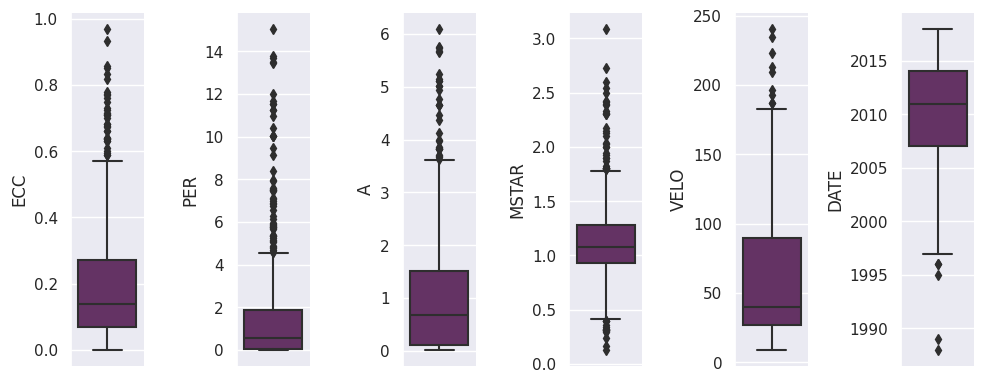

In [171]:
fig, ax = plt.subplots(nrows = 1, ncols = 6, figsize = (10, 4))

for eixo, coluna in zip(range(6), colunas):
    ax[eixo] = sns.boxplot(data = df_boxplots, y = coluna, ax = ax[eixo])
    ax[eixo].spines['top'].set_visible(False)
    ax[eixo].spines['right'].set_visible(False)
    ax[eixo].spines['bottom'].set_visible(False)
    ax[eixo].tick_params(bottom = False)

print(7*' ' ,'media '.ljust(8), 'std '.ljust(6), 'minimo ', 'maximo ', 'moda ')

for coluna in colunas:
    media = np.mean(df_boxplots[coluna])
    std = np.std(df_boxplots[coluna])
    minimo = np.min(df_boxplots[coluna])
    maximo = np.max(df_boxplots[coluna])
    coef_var = std/media
    print(coluna.ljust(7), str(round(media, 3)).ljust(8), str(round(std, 3)).ljust(6), 
          str(round(minimo, 3)).ljust(7), str(round(maximo, 3)).ljust(7), str(round(coef_var, 3)).ljust(7))

fig.tight_layout()
plt.show()

Podemos ver que há muitos outliers. Aqui, quero argumentar que esses outliers são, muito provavelmente, dados reais, e que por isso, não temos motivo para descartá-los.

Nas variáveis como de Período (PER), semieixo maior (A) e, em parte, de velocidades (VELO), os outliers acontecem devido aos viéses de observação de nossos métodos de detecção de exoplanetas. Os principais, como veremos na próxima seção, são os métodos de Trânsito e Velocidade Radial, que são fortemente influenciados por exoplanetas mais massivos ou mais próximos da estrela, logo menor A e menor PER. Se quiser saber mais, [nesse vídeo](https://www.youtube.com/watch?v=YDmGwfJ8qEs&t=632s) a Dr. Becky explica como esses métodos, junto com Imageamento Direto, foram utilizados para detectar exoplanetas no sistema de Alfa Centauri, um sistema de 3 estrelas que está a 4 anos luz da Terra, o sistema mais perto do Sol.

A variável ECC, a excentricidade da órbita, mede o quão oval é a órbita, ou seja, se ecc = 0, a órbita é circular. Quanto maior ecc, mais oval, e mais instável a órbita pois maior a chance de sofrer a influência de outros planetas ou de sua estrela e sair de sua órbita. Logo, a distribuição é uma consequência natural dos sistemas planetários.

A distribuição da variável MSTAR (a massa da estrela hospedeira) é consequencia da Função de Massa Inicial, que mostra que quanto menor a massa da estrela, mais provável a sua formação, exceto em baixas massas, onde as condições locais influenciam a fragmentação da núvem de gás. Logo, a distribuição faz sentido.

A varíavel DATE contêm o ano de descoberta de cada exoplaneta. Como veremos mais pra frente, o número de descobertas de exoplanetas têm crescido exponencialmente. O principal motivo é a criação de missões e telescópios voltados exclusivamente para descoberta de exoplanetas, sendo que em 2010 o telescópio Kepler entrou em operação e contribuiu enormemente para o crescimento, como mostraremos depois.

In [172]:
df_hist = df_g['PER']
df_hist = df_hist.replace(0, np.nan).dropna().reset_index()

0.9039113027409917


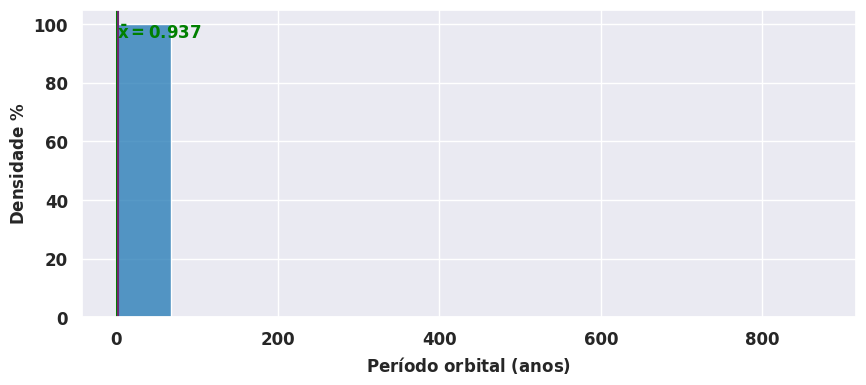

In [173]:
porcentagem = df_hist[df_hist['PER'] <= 1].shape[0]/df_hist.shape[0]
print(porcentagem)
fig, ax = plt.subplots(figsize = (10, 4))

ax.set_xlabel(r'$\mathbf{Período\ orbital\ (anos)}$', fontsize = 12)
ax.set_ylabel(r'$\mathbf{Densidade\ \%}$', fontsize = 12)

def n_bins(n):
    '''Calcula o número de bins para uma distribuição seguindo a Regra de Sturges'''
    nbins = 1 + (10/3)*np.log10(n)
    nbins = int(nbins.round())                         #Arredondando pra cima o valor de bins
    return nbins

bordas(ax)

nbins = n_bins(df_hist.shape[0])

media = round(np.mean(df_hist['PER']), 3)
ax.annotate(xy = (media+.1, 95), text = r'$\mathbf{\bar{x} = aa}$'.replace('aa', str(media)), color = 'green')
ax.axvline(x = media, ymin = 0, ymax = 1.1, color = 'green')
sns.histplot(x = df_hist['PER'], bins = nbins, color = '#1f77b4', stat='percent')
ax.axvline(x = 1.6)

plt.ylim(0, 105)
plt.show()

## 4.2 Métodos de descobertas

Aqui, veremos quais os métodos mais utilizados de nossa base de dados

In [174]:
df_disc = df_g[['NAME', 'PLANETDISCMETH']]
hist_disc = df_disc.groupby(['PLANETDISCMETH'])[['NAME']].count().sort_values(by = 'NAME', ascending = False)
hist_disc['PLANETDISCMETH'] = hist_disc.index
total = hist_disc['NAME'].sum()
hist_disc['porcentagem (%)'] = round(100*hist_disc['NAME']/total, 2)
hist_disc.reset_index(drop = True)

,NAME,PLANETDISCMETH,porcentagem (%)
0,2636,Transit,80.86
1,587,RV,18.01
2,16,Microlensing,0.49
3,10,Imaging,0.31
4,10,Timing,0.31
5,1,Transit Timing Variations,0.03


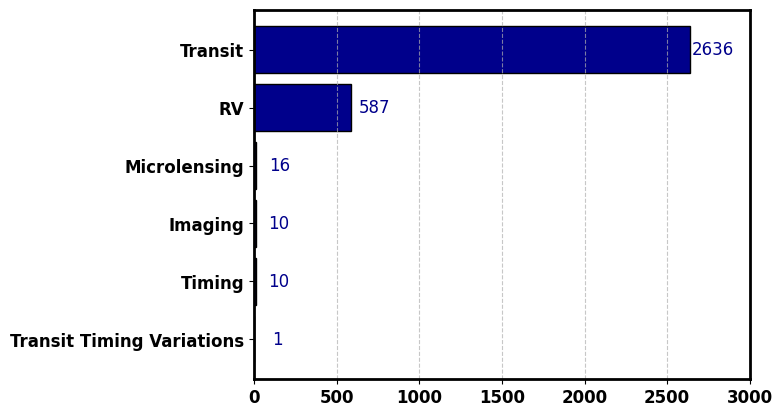

In [175]:
plt.style.use('default')
fig, ax = plt.subplots()

ax.barh(hist_disc['PLANETDISCMETH'], hist_disc['NAME'], color = 'darkblue', edgecolor = 'black')
plt.gca().invert_yaxis()

for i, valor in enumerate(hist_disc['NAME']):
    ax.text(valor + 140, i, valor, color = 'darkblue', fontsize = 12, ha = 'center', va = 'center')

ax.set_xlim(0, 3000)
ax.grid(axis="x", linestyle="--", alpha=0.7)
bordas(ax)
plt.show()

Lançado em 2009 pela NASA, a missão do Kepler iria monitorar durante quatro anos, através do método de Trânsito, cerca de 150 mil estrelas na direção da constelação de Cygnus, com o objetivo principal de determinar qual a fração de estrelas do tipo solar contêm planetas do tipo Terra dentro da zona habitável. 

Geralmente, o nome dos exoplanetas têm o nome do telescópio que o descobriu, por exemplo, Kepler-107 d. Vamos calcular quantos exoplanetas foram descobertos pelo telescópio Kepler.

In [176]:
total = df_g.shape[0]
kepler = df_disc.query("NAME.str.contains('Kepler')").shape[0]
print(f'''Dos {total} exoplanetas da base, {kepler} ({round(100*kepler/total, 2)} %) foram descobertos pela missão Kepler.''')

Dos 3261 exoplanetas da base, 2251 (69.03 %) foram descobertos pela missão Kepler.


## 4.3 Número de exoplanetas descobertos

Aqui, vamos entender como o número de exoplanetas foi crescendo durante os anos

In [177]:
df_descobertas = df_g[['NAME', 'DATE']]  # Selecionando apenas as colunas utilizadas
df_desc_limpo = df_descobertas.replace(0, np.nan).dropna().reset_index(drop = True)
df_desc_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3261 entries, 0 to 3260
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NAME    3261 non-null   object
 1   DATE    3261 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 51.1+ KB


In [178]:
frequencia = df_desc_limpo.groupby('DATE').count()
frequencia_acumulada = frequencia.cumsum()
frequencia_acumulada.head()

,NAME
DATE,
1988,1
1989,2
1992,4
1993,5
1994,6


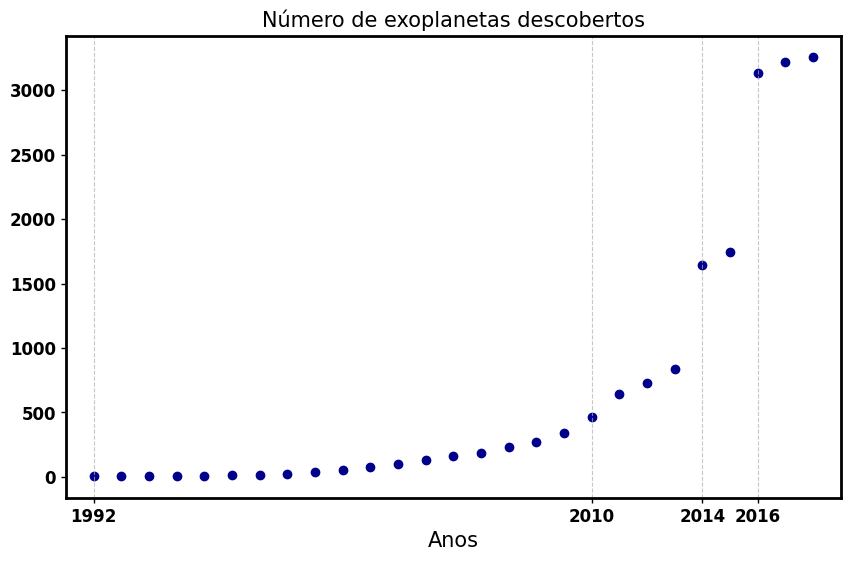

In [179]:
'''Definindo a figura'''

plt.style.use('default')

fig, ax = plt.subplots(figsize = (10, 6))


'''Plotando o gráfico'''
ax.set_title('Número de exoplanetas descobertos', fontsize = 15)
ax.scatter(x = frequencia_acumulada.index, y = frequencia_acumulada.values, color='darkblue')
ax.set_xlabel('Anos', fontsize = 15)
ax.set_xticks([1992, 2010, 2014, 2016 ])
ax.set_xlim(1991, 2019)
ax.tick_params(axis='both', colors='black', width= 1)
ax.grid(axis="x", linestyle="--", alpha=0.7)

bordas(ax)

fig.show()

Vamos determinar quantos exoplanetas kepler detectou em 2014 e 2016

In [180]:
frequencia.tail()   # no total foram 813 em 2014 e 1386 em 2016.

,NAME
DATE,
2014,813
2015,101
2016,1386
2017,87
2018,40


In [181]:
df_descobertas_2014 = df_desc_limpo[df_desc_limpo['DATE'] == 2014]
df_descobertas_2016 = df_desc_limpo[df_desc_limpo['DATE'] == 2016]

In [182]:
df_descobertas_2014.query("NAME.str.contains('Kepler')").shape

(766, 2)

In [183]:
df_descobertas_2016.query("NAME.str.contains('Kepler')").shape

(1284, 2)

Os dois grandes saltos da Figura anterior, em 2014 e 2016, são frutos das observações advindas do Telescópio Kepler. Dos 813 exoplanetas descobertos em 2014, 766 foram revelados por este. Já em 2016, dos 1386 descobertos, 1284 são atribuídos ao telescópio. Esses dois momentos separados de descobertas se devem à descontinuidade da missão Kepler. A missão estava prevista para durar quatro anos, mas em 2012 e 2013 o telescópio perdeu duas das quatro rodas de reação que o mantinham estável e a primeira missão do telescópio se encerrou. Os engenheiros da NASA descobriram como contornar o problema e reviveram o telescópio, mas agora com a missão K2. Foi nesse momento que conseguiram retornar à busca por exoplanetas com o telescópio e obtiveram quase o dobro de novos exoplanetas descobertos.

## 4.4 Verificação da Primeira Lei de Kepler (Excentricidades)

A primeira Lei de Kepler diz: a órbita de qualquer planeta ao redor do Sol é uma elipse com o Sol em um dos focos;
Ou seja, diferente do que acreditavam antes de Kepler, as órbitas não sao círculos perfeitos, mas elipses. Kepler conseguiu mostrar que essa lei é verdade para os planetas do Sistema Solar. Aqui, vamos demonstrar essa Lei para outros exoplanetas

In [184]:
df_ecc = df_g[['NAME', 'ECC', 'ECCUPPER', 'ECCLOWER', 'PER', 'PERLOWER', 'PERUPPER']]
df_ecc = df_ecc.dropna().reset_index(drop = True)
df_ecc.isna().sum()

NAME        0
ECC         0
ECCUPPER    0
ECCLOWER    0
PER         0
PERLOWER    0
PERUPPER    0
dtype: int64

In [185]:
# É importante separarmos os exoplanetas que têm excentricidade igual a 0
df_ecc_0 = df_ecc[df_ecc['ECC'] == 0]
df_ecc_0.shape

(108, 7)

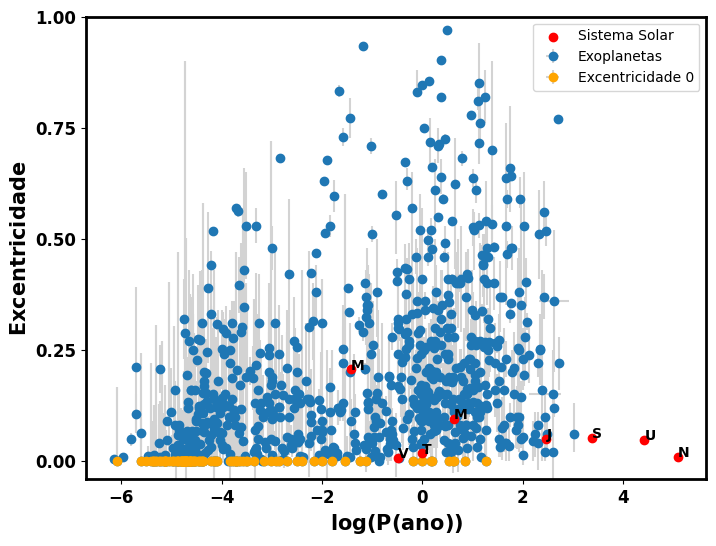

In [186]:
plt.style.use('default')
fig, ax = plt.subplots(figsize = (8, 6))

'''Plotando os dados com margem de erro'''
def ecc_errorbar(df, cor, label):
    ax.errorbar(x = np.log(df['PER']), y = df['ECC'], 
                xerr = [df['PERLOWER']/(df['PER']*np.log(10)), df['PERUPPER']/(df['PER']*np.log(10))],   # aqui estamos colocando o período em escala logarítimica
                yerr = [df['ECCLOWER'], df['ECCUPPER']], fmt = 'o', color = cor, ecolor='#d3d3d3',
                alpha = 1, label = label)

ecc_errorbar(df_ecc, cor = '#1f77b4', label = 'Exoplanetas')
ecc_errorbar(df_ecc_0, cor = 'orange', label = 'Excentricidade 0')

'''Editando o gráfico'''
ax.set_xlabel(r'$\mathbf{log(P(ano))}$', fontsize = 15)
ax.set_ylabel(r'$\mathbf{Excentricidade}$', fontsize = 15)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylim(-0.04, 1)

bordas(ax)

plt.scatter(x = np.log(planetas['PER']), y = planetas['ECC'], c = 'red', zorder = 10, label = 'Sistema Solar')

for i, j, k in zip(planetas['PER'], planetas['ECC'], planetas['NAME']):
    ax.annotate(xy = (np.log(i), j), text = f'{k}', zorder = 10, fontweight='bold')

ax.legend()
fig.show()

In [187]:
sum(df_ecc.ECC == 0)/df_ecc['ECC'].shape[0]

0.13316892725030827

Podemos observar que de fato, o número de exoplanetas com excentricidade diferente de 0 (representados em azul), ou seja, que realizam um movimento de elipse em torno da sua respectiva estrela é predominante. Na verdade, apenas 13% (108 de 811) dos exoplanetas de nossa amostra têm excentricidade igual a 0 (representados em amarelo). Confirmando a validade da Primeira Lei de Kepler para planetas fora do Sistema Solar.

Também podemos observar que os planetas do Sistema Solar apresentam uma excentricidade baixa em relação à nossa amostra. Esse é um dos motivos pelos quais os astrônomos demoraram tanto para descrever corretamente as órbitas dos planetas. De fato, Mercúrio é o que tem maior excentricidade, mas é frequentemente bloqueado pelo Sol. Já Marte, o segundo com maior excentricidade apresenta uma janela de tempo muito maior para ser estudado.

## 4.5 3ª Lei de Kepler na forma das velocidades

Para a análise a seguir, realizaremos o gráfico da velocidade dos planetas em função do semieixo maior. Essa análise é relacionada à Terceira Lei de Kepler, conhecida como a versão da velocidade:

$$v = v_T\sqrt{\frac{M}{A}}$$

Como demonstrado em nosso trabalho, a partir da Lei da Gravitação Universal, que é uma lei deduzida de princípios físicos, e introduzindo a Terceira Lei de Kepler, que é uma lei empírica, encontramos a velocidade de cada exoplaneta. Como a massa e o semieixo maior são obtidos por métodos indiretos, temos uma forma de reforçar o entendimento de que a Terceira Lei de Kepler se aplica a outros sistemas planetários.


In [188]:
df = df_g[['NAME', 'A', 'AUPPER', 'ALOWER', 'VELO', 'VELOLOWER', 'VELOUPPER']]
df_velo_limpo = df.replace(0, np.nan).dropna().reset_index(drop = True)
df_velo_limpo.head()

,NAME,A,AUPPER,ALOWER,VELO,VELOLOWER,VELOUPPER
0,Kepler-1049 b,0.043166,4.668087e-08,4.668087e-08,102.705631,3.020754,3.020754
1,Kepler-813 b,0.140047,3.638537e-07,3.638537e-07,77.822590,2.867148,2.047963
2,Kepler-427 b,0.092635,6.601162e-09,6.601162e-09,96.189586,3.005925,3.005925
3,Kepler-1056 b,0.178367,6.301133e-07,6.301133e-07,74.874303,4.011123,6.685206
4,Kepler-1165 b,0.087693,3.644578e-07,3.644578e-07,107.259861,3.796809,5.695214


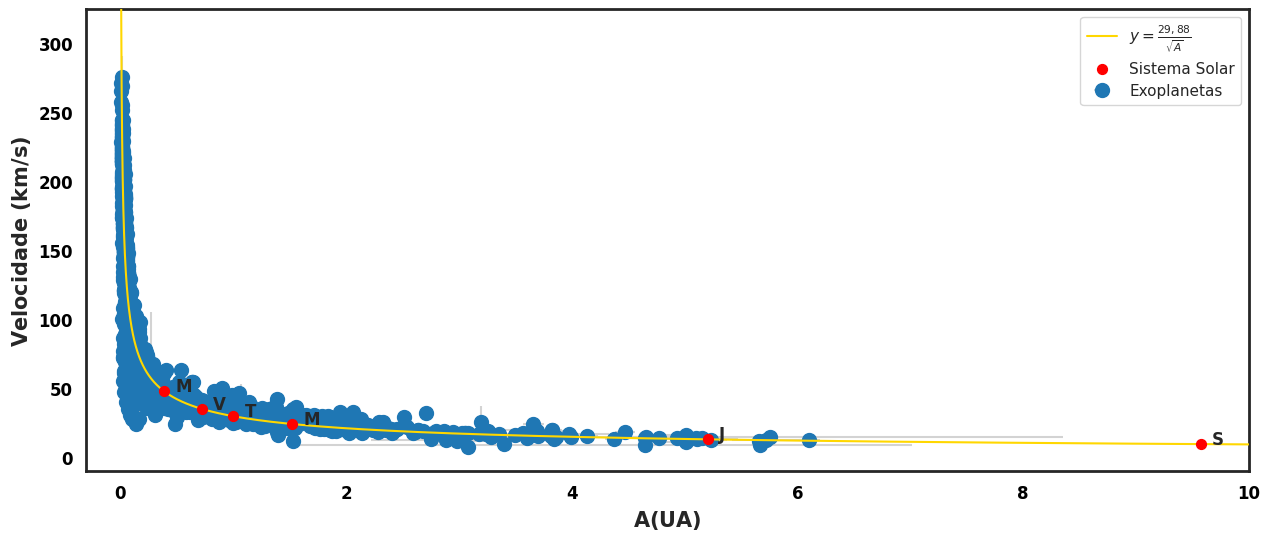

In [189]:
sns.set_theme(style = 'white')
fig, ax = plt.subplots(figsize = (15, 6))

ax.errorbar(x = df_velo_limpo['A'], y = df_velo_limpo['VELO'], 
            xerr = [df_velo_limpo['ALOWER'], df_velo_limpo['AUPPER']],
            yerr = [df_velo_limpo['VELOUPPER'], df_velo_limpo['VELOLOWER']], fmt = 'o', color='#1f77b4', ecolor='#d3d3d3',
            alpha = 1, label = 'Exoplanetas', markersize = 10)

ax.set_xlabel(r'$\mathbf{A (UA)}$', fontsize = 15)
ax.set_ylabel(r'$\mathbf{Velocidade\ (km/s)}$', fontsize = 15)
ax.set_ylim(-10, 324.5)
ax.set_xlim(-.3, 10)

ax.tick_params(axis='both', colors='black', width= 1)

bordas(ax)

x = []
z = []
for i in np.arange(0.001, 35, 0.0001):
    x.append(i)
    z.append((1/i**.5)*29.88)
ax.plot(x, z, alpha = 1, label = r'$y = \frac{29,88}{\sqrt{A}}$', c = 'gold', zorder = 10)      # gera o plot

for i, j, k in zip(planetas['A'], planetas['VELO'], planetas['NAME']):
    ih = i + .1
    jh = j + 10
    ax.annotate(xy = (ih, j), text = f'{k}', zorder = 10, fontweight='bold')

ax.scatter(x = planetas['A'], y = planetas['VELO'], color = 'red', zorder = 10, label = 'Sistema Solar', s = 50)

plt.legend()
plt.show()

Após selecionar uma amostra com dados não nulos de A, A, MSTAR e MSTAR, calculamos diretamente da Equação 6 e graficamos a velocidade de 2329 exoplanetas e dos oito planetas do Sistema Solar, junto das respectivas margens de erro propagadas, representadas pelas linhas cinzas. Ou seja, utilizamos a massa das estrelas hospedeiras e o semieixo maior da órbita dos exoplanetas, para realizar o gráfico. Além disso, graficamos a função $y = \frac{29,88}{\sqrt{A}}$, para comparar o quanto ela se aproxima da velocidade calculada para os exoplanetas.

Diferentemente das outras figuras que estão em escala logarítmica, o fato desta estar em escala linear deixa bem evidente a diferença dos planetas do Sistema Solar para os exoplanetas de outros sistemas planetários de nossa amostra. Saturno, Urano e Netuno encontram-se a, respectivamente, 9,6, 19,2 e 30,2 UA do Sol. Nenhum exoplaneta de nossa base está acima de 8,3 UA (considerando a margem de erro). O que deixa as seguintes perguntas: será que, diante de tantos sistemas planetários, o nosso é especial? E se não, quantos exoplanetas estamos deixando de observar devido aos viéses de observação?

A dispersão de pontos ao redor da função $y = \frac{29,88}{\sqrt{A}}$ pode ser explicada pelo seguinte fato: quando Newton deduziu a Terceira Lei de Kepler, observou que o valor de k dependia da massa do planeta e da estrela hospedeira. Como a massa das estrelas é muito maior que a massa dos planetas, podemos aproximar k a uma constante, mas a realidade é que ele pode variar. Como há uma distribuição de massas das estrelas em nossa amostra, é natural que haja uma dispersão de pontos em torno da Equação que é válida para o Sistema Solar. 

## 4.6 Separação por Massas

A próxima figura, criada a partir da amostra da anterior, ressalta melhor as variações observadas. Nela conseguimos ver mais especificamente como a velocidade dos planetas se comporta para diferentes intervalos de massa das estrelas hospedeiras. Sendo que os exoplanetas estão quase igualmente distribuídos, contendo entre 355 e 414 exoplanetas por gráfico. Pela diferença no tamanho dos intervalos, podemos ver que há uma alta concentração de estrelas com massa do tipo solar, assim como vimos no boxplot da MSTAR. Além disso, vemos que em todos os intervalos os pontos estão bem próximos da função graficada, principalmente para estrelas cuja massa é próxima à do Sol. E, conforme os intervalos de massas se distanciam de 1 M☉, a dispersão dos pontos se acentua.

In [190]:
df_massas = df_g[['NAME', 'A', 'AUPPER', 'ALOWER', 'MSTAR', 'MSTARLOWER', 'MSTARUPPER', 'VELO', 'VELOLOWER', 'VELOUPPER']]
df_massas = df_massas.replace(0, np.nan).dropna()
df_massas = df_massas.sort_values(by = 'MSTAR').reset_index(drop = True)
df_massas.head(3)

,NAME,A,AUPPER,ALOWER,MSTAR,MSTARLOWER,MSTARUPPER,VELO,VELOLOWER,VELOUPPER
0,TRAPPIST-1 h,0.138277,3.929445e-07,3.929445e-07,0.089,0.006,0.006,23.971815,0.808039,0.808039
1,TRAPPIST-1 b,0.025780,4.436445e-09,4.436445e-09,0.089,0.006,0.006,55.517544,1.871378,1.871378
2,TRAPPIST-1 d,0.049748,6.387407e-07,6.387407e-07,0.089,0.006,0.006,39.965907,1.347165,1.347165


In [191]:
classe_a = df_massas.iloc[:391]
classe_b = df_massas.iloc[391:805]
classe_c = df_massas.iloc[805:1170]
classe_d = df_massas.iloc[1170:1572]    # definidos à mão de acordo com as massas da estrelas, ver próximos gráficos
classe_e = df_massas.iloc[1572:1927]
classe_f = df_massas.iloc[1927:]

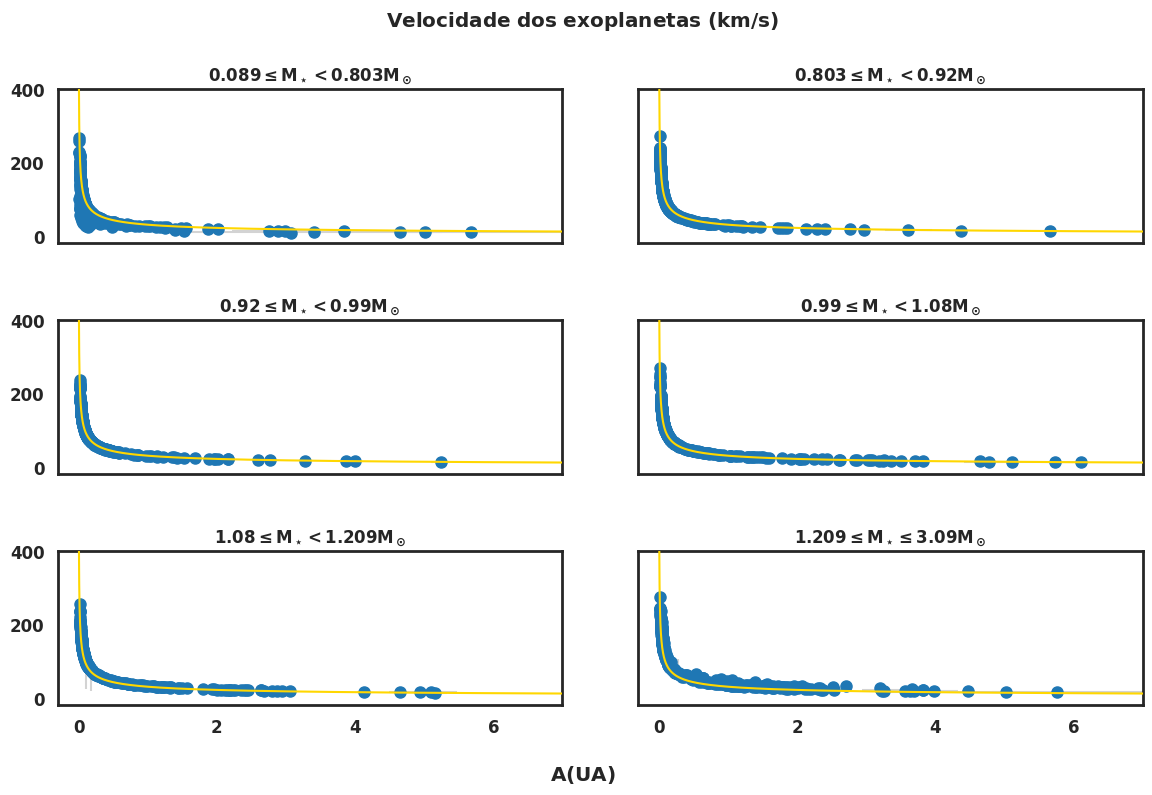

In [192]:
sns.set_theme(style = 'white')
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (14, 8))
fig.subplots_adjust(hspace = 0.5, wspace = 0.15)

def grafico(axx, axy, classe):
    x = []
    y = []
    for i in np.arange(0.002, 7, 0.0001):
        x.append(i)
        y.append((1/i**.5)*29.88)
    ax[axx, axy].plot(x, y, c = 'gold', zorder = 10)      # gera o plot
    ax[axx, axy].set_ylim(-20, 400)
    ax[axx, axy].set_xlim(-.3, 7)
    ax[axx, axy].set_xticks([]) if axx != 2 else ax[axx, axy].set_xticks([0, 2, 4, 6])
    ax[axx, axy].set_yticks([]) if axy != 0 else ax[axx, axy].set_yticks([0, 200, 400])
    bordas(ax[axx, axy])
    ax[axx, axy].errorbar(x = classe['A'], y = classe['VELO'], markersize = 8,
                xerr = [classe['ALOWER'], classe['AUPPER']],
                yerr = [classe['VELOUPPER'], classe['VELOLOWER']], fmt = 'o', color='#1f77b4', ecolor='#d3d3d3',)

classes = [classe_a, classe_b, classe_c, classe_d, classe_e, classe_f]
titulos = [r'$\bf{0.089 \leq M_\star < 0.803 M_\odot}$', r'$\bf{0.803 \leq M_\star < 0.92 M_\odot}$', r'$\bf{0.92 \leq M_\star < 0.99 M_\odot}$',\
           r'$\bf{0.99 \leq M_\star < 1.08 M_\odot}$', r'$\bf{1.08 \leq M_\star < 1.209 M_\odot}$', r'$\bf{1.209 \leq M_\star \leq 3.09 M_\odot}$']

for i in range(3):
    for j in range(2):
        try:
            grafico(i, j, classes[0])
            ax[i, j].set_title(titulos[0])
            classes.pop(0)
            titulos.pop(0)
        except:
            pass

fig.suptitle(r'$\mathbf{Velocidade\ dos\ exoplanetas\ (km/s)}$')
fig.supxlabel(r'$\mathbf{A (UA)}$')
plt.show()

## 4.7 Aplicação da 3ª Lei de Kepler

Utilizando uma amostra com 3166 exoplanetas, realizamos o gráfico dos períodos e semieixos maiores segundo a Terceira Lei de Kepler cujas estrelas hospedeiras têm massas próximas à do Sol, $0,9M☉ \leq M* < 1,1M☉$. No que tange os resultados apresentados, cada um dos parâmetros, período e semieixo maior, podem ser obtidos de diferentes formas, a depender do método de detecção. Como explicado anteriormente, o telescópio Kepler obteve o período observando o trânsito de cada planeta e nós calculamos o semieixo maior segundo a Terceira Lei de Kepler.

In [193]:
df_ter = df_g[['NAME', 'A', 'AUPPER', 'ALOWER', 'PER', 'PERUPPER', 'PERLOWER']]

In [194]:
df_ter = df_ter.replace(0, np.nan).dropna().reset_index(drop = True)

In [195]:
df_ter['A^3'] = df_ter['A']**3
df_ter['deltaAUPPER^3'] = 3*df_ter['A']**2*df_ter['AUPPER']
df_ter['deltaALOWER^3'] = 3*df_ter['A']**2*df_ter['ALOWER']

df_ter['PER^2'] = df_ter['PER']**2
df_ter['deltaPERUPPER^2'] = 2*df_ter['PER']*df_ter['PERUPPER']
df_ter['deltaPERLOWER^2'] = 2*df_ter['PER']*df_ter['PERLOWER']

In [196]:
planetas['A^3'] = planetas['A']**3
planetas['PER^2'] = planetas['PER']**2

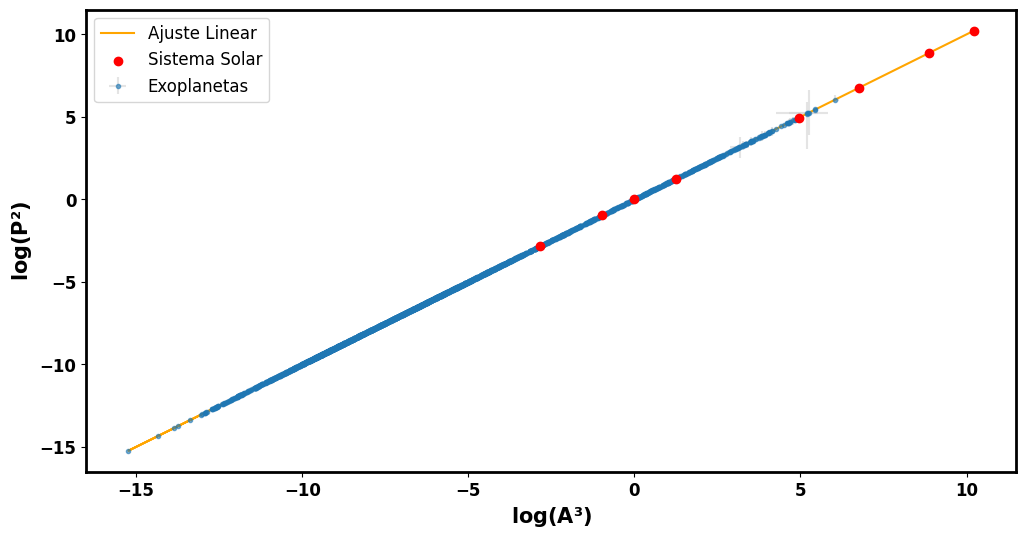

In [197]:
'''definindo o estilo da imagem e criando a figura'''
plt.style.use('default')  
fig, ax = plt.subplots(figsize = (12, 6))

'''Realizando o ajusto dos pontos'''
inclinacao, intercept = np.polyfit(np.log(pd.concat([df_ter['A^3'],planetas['A^3']])), 
                                   np.log(pd.concat([df_ter['PER^2'], planetas['PER^2']])), 1)

'''Plotando o gráfico com as margens de erro e a reta ajustada'''
ax.errorbar(x = np.log(df_ter['A^3']), y = np.log(df_ter['PER^2']), 
            xerr = [df_ter['deltaALOWER^3']/(np.log(10)*df_ter['A^3']), df_ter['deltaAUPPER^3']/(np.log(10)*df_ter['A^3'])],
            yerr = [df_ter['deltaPERLOWER^2']/df_ter['PER^2'], df_ter['deltaPERUPPER^2']/df_ter['PER^2']],
            fmt = '.', color='#1f77b4', ecolor='#d3d3d3', alpha = 0.6, label = 'Exoplanetas', zorder = 0)

ax.plot(np.log(pd.concat([df_ter['A^3'],planetas['A^3']])), inclinacao * np.log(pd.concat([df_ter['A^3'],planetas['A^3']])) + intercept, color = 'orange', 
         label = 'Ajuste Linear', zorder = 0)  # plot da reta

ax.scatter(np.log(planetas['A^3']), np.log(planetas['PER^2']), color = 'red', marker = 'o', label = 'Sistema Solar')

'''Editando o gráfico principal'''
ax.set_xlabel(r'$\mathbf{log(A³)}$', fontsize = 15)    
ax.set_ylabel(r'$\mathbf{log(P²)}$', fontsize = 15)

bordas(ax)

'''Realizando o Plot'''
ax.legend(loc = 'upper left', fontsize = 12)
fig.show()